# Risco de atraso em pedidos da Olist

## Desafio de negócio

Identificar, **logo após a aprovação do pagamento**, quais pedidos possuem maior risco de serem entregues depois do prazo prometido.

### Objetivos

- estimar futuramente a probabilidade de atraso de cada pedido;
- explicar os principais fatores associados ao risco;
- apoiar uma decisão operacional baseada em custos e capacidade.

> Este notebook não pretende realizar um EDA completo. Ele apresenta uma experiência reduzida e orientada por hipóteses, adequada para uma aula curta.

## Roteiro da experiência

1. Definir o alvo e o instante da previsão.
2. Carregar e verificar as tabelas.
3. Integrar os dados mantendo **uma linha por pedido**.
4. Investigar cinco perguntas orientadas por hipóteses.
5. Registrar conclusões e possíveis features.

**Pergunta central:** quais características disponíveis após a aprovação do pagamento estão associadas ao atraso?

In [13]:
# Bibliotecas para caminhos, manipulação de dados e visualização.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Configura a exibição das tabelas e o estilo dos gráficos.
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="Blues_r")


# Define os caminhos principais do projeto.
ROOT = Path.cwd().parents[0]
DATA_DIR = ROOT / "data"


# Exibe o caminho da pasta onde estão os dados.
DATA_DIR

WindowsPath('C:/Users/HANDRA19/Workbench/2-Cimatec/MachineLearning/10_08-Olist/data')

## 1. Instante da previsão e risco de data leakage

O modelo deverá gerar a previsão no instante `order_approved_at`. Assim, somente informações já conhecidas até esse momento poderão ser usadas como features.

| Disponível na previsão | Informação futura (não usar como feature) |
|---|---|
| data da compra e aprovação | data de envio à transportadora |
| prazo prometido | data real da entrega |
| cliente e localização | avaliação e comentário do cliente |
| itens, vendedores, preço e frete | status ou eventos posteriores |

> A data real da entrega será utilizada apenas para construir o target. Ela não poderá entrar como variável explicativa do modelo.

## 2. Carregamento das tabelas

Utilizaremos quatro tabelas obrigatórias para o nosso cenário

In [8]:
# Mapeia os nomes dos datasets para seus arquivos CSV.
FILES = {
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
}

# Lista as colunas que devem ser interpretadas como datas.
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

# Carrega a base de pedidos, convertendo automaticamente as colunas de data.
orders = pd.read_csv(
    DATA_DIR / "raw" / FILES["orders"],
    parse_dates=date_columns,
)

# Carrega as bases de itens dos pedidos e clientes.
items = pd.read_csv(DATA_DIR / "raw" / FILES["items"])
customers = pd.read_csv(DATA_DIR / "raw" / FILES["customers"])

# Exibe a quantidade de linhas e colunas de cada base carregada.
print("Pedidos:", orders.shape)
print("Itens:", items.shape)
print("Clientes:", customers.shape)

Pedidos: (99441, 8)
Itens: (112650, 7)
Clientes: (99441, 5)


## 3. Construção do alvo

Para simplificar a experiência, usaremos apenas pedidos com status `delivered` e data real de entrega conhecida.


$$
is\_late = 1 \quad \text{se entrega real > entrega prometida}
$$


In [14]:
# Seleciona apenas os pedidos que podem ser utilizados para construir
# o histórico de entregas atrasadas e realizadas dentro do prazo.
delivered_orders = orders.loc[
    # Mantém somente pedidos que foram efetivamente entregues.
    orders["order_status"].eq("delivered")

    # Remove pedidos sem a data real em que o cliente recebeu a compra.
    # Essa data é necessária para saber se o pedido atrasou.
    & orders["order_delivered_customer_date"].notna()

    # Remove pedidos sem a data de entrega prometida ao cliente.
    # Sem essa informação, não é possível comparar o previsto com o realizado.
    & orders["order_estimated_delivery_date"].notna()

    # Mantém somente pedidos com a data de aprovação do pagamento.
    # Esse é o momento definido para realizar a previsão.
    & orders["order_approved_at"].notna()
].copy()  # Cria uma cópia independente para evitar alterações no DataFrame original.


# Cria a variável-alvo do problema:
# 1 → pedido entregue depois da data prometida;
# 0 → pedido entregue dentro do prazo ou antes da data prometida.
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"]
).astype("int8")  # Armazena 0 e 1 usando um tipo inteiro que ocupa menos memória.


# Apresenta a quantidade total de pedidos antes da aplicação dos filtros.
print(f"Pedidos originais: {len(orders):,}")


# Apresenta quantos pedidos permaneceram após aplicação do filtro
print(f"Pedidos filtrados: {len(delivered_orders):,}")


# Mostra a quantidade de pedidos em cada classe:
# 0 = entregue no prazo;
# 1 = entregue com atraso.
display(
    delivered_orders["is_late"].value_counts(dropna=False)
)

Pedidos originais: 99,441
Pedidos filtrados: 96,456


is_late
0    88630
1     7826
Name: count, dtype: int64

## 4. Integração no nível do pedido

A tabela de itens tem várias linhas para o mesmo pedido. Antes do `merge`, precisamos agregá-la. Caso contrário, a unidade de análise deixaria de ser o pedido e alguns pedidos teriam peso maior simplesmente por possuírem mais itens.

### 4.1 Agregação

In [10]:
# A tabela de itens possui uma linha para cada item presente no pedido.
# Portanto, um mesmo order_id pode aparecer várias vezes.
#
# Como o objetivo é construir uma base com uma linha por pedido,
# precisamos agrupar os itens antes de integrar essa tabela às demais.
items_agg = (
    items.groupby(
        "order_id",       # Agrupa todos os itens pertencentes ao mesmo pedido.
        as_index=False,   # Mantém order_id como uma coluna comum.
    )
    .agg(
        # Conta quantas linhas de itens existem em cada pedido.
        # Um pedido com três produtos registrados terá item_count igual a 3.
        # nome_da_nova_coluna=("coluna_original", "função")
        item_count=("order_item_id", "count"),

        # Conta quantos vendedores diferentes participam do pedido.
        # O nunique evita contar o mesmo vendedor mais de uma vez.
        # nome_da_nova_coluna=("coluna_original", "função")
        seller_count=("seller_id", "nunique"),

        # Soma os preços dos itens para obter o valor total dos produtos
        # presentes no pedido.
        # nome_da_nova_coluna=("coluna_original", "função")
        total_price=("price", "sum"),

        # Soma o frete de todos os itens para obter o valor total de frete
        # associado ao pedido.
        total_freight=("freight_value", "sum"),
    )
)


# Verifica se cada pedido aparece somente uma vez após a agregação.
#
# Se a condição for falsa, o Python interromperá a execução e lançará
# um AssertionError. Essa checagem ajuda a garantir que a unidade de
# análise da nova tabela é realmente o pedido.
assert items_agg["order_id"].is_unique


# Exibe as cinco primeiras linhas da tabela agregada.
items_agg.head()

,order_id,item_count,seller_count,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14


### 4.2 Merge

In [11]:
# Começa com os pedidos entregues que possuem as datas necessárias
# para determinar se houve atraso.
orders_analysis = (
    delivered_orders

    # Adiciona as informações agregadas dos itens:
    # quantidade de itens, vendedores, preço total e frete total.
    .merge(
        items_agg,
        on="order_id",            # Coluna usada para relacionar as tabelas.
        how="left",               # Mantém todos os pedidos de delivered_orders.
        validate="one_to_one",    # Verifica se order_id é único nas duas tabelas.
    )

    # Adiciona a localização do cliente.
    .merge(
        customers[
            ["customer_id", "customer_state", "customer_city",]
        ],
        on="customer_id",         # Relaciona cada pedido ao seu cliente.
        how="left",               # Mantém todos os pedidos da base anterior.
        validate="many_to_one",   # Vários pedidos podem apontar para um cliente.
    )
)

assert orders_analysis["order_id"].is_unique, "A base final deve manter uma linha por pedido."
assert len(orders_analysis) == len(delivered_orders), "A integração alterou o total de pedidos."

print("Dimensão da base analítica:", orders_analysis.shape)
orders_analysis.head()

Dimensão da base analítica: (96456, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,item_count,seller_count,total_price,total_freight,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,1,1,29.99,8.72,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,1,1,118.70,22.76,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,1,1,159.90,19.22,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,1,1,45.00,27.20,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,1,1,19.90,8.72,SP,santo andre


## 5. Criação de Novas Variáveis

Estas variáveis são construídas apenas com dados conhecidos até a aprovação do pagamento.

In [12]:
# Calcula quantos dias a empresa prometeu para realizar a entrega,
# considerando como início o momento da aprovação do pagamento.
orders_analysis["promised_days"] = (
    orders_analysis["order_estimated_delivery_date"]  # Data prometida para a entrega.
    - orders_analysis["order_approved_at"]            # Data de aprovação do pagamento.
).dt.total_seconds().div(86_400)          # Converte segundos para dias => 24 * 60 * 60 = 86.400 segundos


# Extrai o número do mês em que a compra foi realizada.
# Exemplo: janeiro = 1, fevereiro = 2, ..., dezembro = 12.
orders_analysis["purchase_month"] = (
    orders_analysis["order_purchase_timestamp"].dt.month
)


# Extrai o dia da semana em que a compra foi realizada.
#
# O Pandas representa os dias da seguinte forma:
# 0 = segunda-feira
# 1 = terça-feira
# 2 = quarta-feira
# 3 = quinta-feira
# 4 = sexta-feira
# 5 = sábado
# 6 = domingo
orders_analysis["purchase_weekday"] = (
    orders_analysis["order_purchase_timestamp"].dt.dayofweek
)


# Extrai a hora em que a compra foi realizada.
# Os valores variam de 0 a 23.
#
# Exemplo:
# 0  = meia-noite
# 8  = 8 horas
# 14 = 14 horas
# 23 = 23 horas
orders_analysis["purchase_hour"] = (
    orders_analysis["order_purchase_timestamp"].dt.hour
)


# Gera estatísticas descritivas para o prazo prometido:
# quantidade, média, desvio-padrão, mínimo, quartis e máximo.
#
# describe() gera as estatísticas.
# to_frame() transforma o resultado em DataFrame.
# .T transpõe a tabela para que as estatísticas apareçam como colunas.
display(
    orders_analysis["promised_days"].describe().to_frame().T
)


# Conta quantos pedidos apresentam prazo prometido menor ou igual a zero.
#
# Esses casos seriam suspeitos porque significariam que a data prometida
# ocorreu antes ou exatamente no momento da aprovação do pagamento.
print(
    "Prazos não positivos:",
    orders_analysis["promised_days"].le(0).sum()
)

,count,mean,std,min,25%,50%,75%,max
promised_days,96456.0,23.306482,8.765103,-6.664225,17.905885,22.668762,28.066727,153.57603


Prazos não positivos: 6


# Pergunta 1: Qual é a frequência de pedidos atrasados?

**Hipótese:** os atrasos são minoritários, produzindo desbalanceamento entre as classes.

**Discussão:** se um modelo sempre previsse “não atrasará”, qual seria sua acurácia? Ela seria suficiente para avaliar o modelo?

In [15]:
taxa_atraso = orders_analysis['is_late'].value_counts(normalize=True) * 100
display(taxa_atraso)

is_late
0    91.886456
1     8.113544
Name: proportion, dtype: float64

**Conclusão da pergunta 1:** escreva aqui o que os dados mostraram.

- Taxa de atraso: `8,11%`
- A hipótese foi apoiada? `Sim`
- Implicação para a modelagem: `Acurácia não é adequada.`

# Pergunta 2: Pedidos com prazos menores atrasam mais?

**Hipótese:** quando a empresa promete entregar em poucos dias, existe menos
margem para problemas logísticos e o pedido pode apresentar maior risco de atraso.


,mean,count
promised_days_bins,,
"(-6.665, 16.306]",0.086824,19292
"(16.306, 21.045]",0.097558,19291
"(21.045, 24.548]",0.086875,19292
"(24.548, 29.537]",0.080145,19290
"(29.537, 153.576]",0.054274,19291


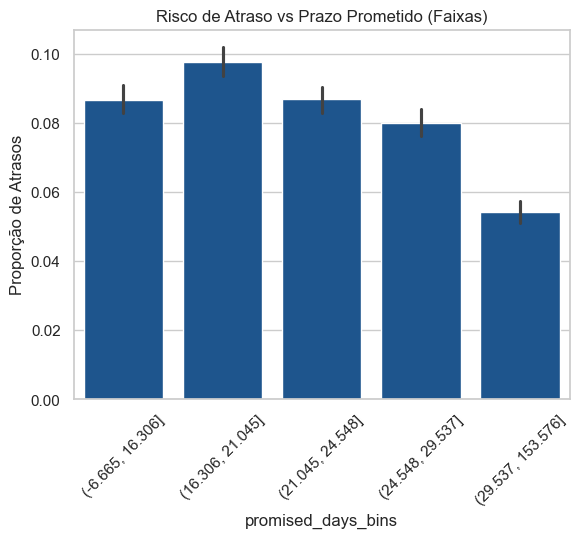

In [16]:
# Criando faixas de prazos prometidos (ex: quantis) para facilitar a visualização
orders_analysis['promised_days_bins'] = pd.qcut(orders_analysis['promised_days'], q=5)

# Calculando a taxa de atraso média por faixa de prazo
risco_por_prazo = orders_analysis.groupby('promised_days_bins', observed=True)['is_late'].agg(['mean', 'count'])
display(risco_por_prazo)

# Gráfico
sns.barplot(data=orders_analysis, x='promised_days_bins', y='is_late')
plt.xticks(rotation=45)
plt.title("Risco de Atraso vs Prazo Prometido (Faixas)")
plt.ylabel("Proporção de Atrasos")
plt.show()

**Conclusão da pergunta 2:** a taxa muda de forma consistente entre as faixas? Há faixas com poucas observações?  

A taxa de atraso não costuma ser maior apenas nos prazos curtos. A taxa de atraso para a faixa de 21 <-> 24 dias é quase a mesma para -6 <-> 16 dias.

# Pergunta 3: Pedidos maiores ou mais complexos atrasam mais?

**Hipótese:** pedidos com mais itens ou vendedores apresentam maior complexidade logística e maior risco.

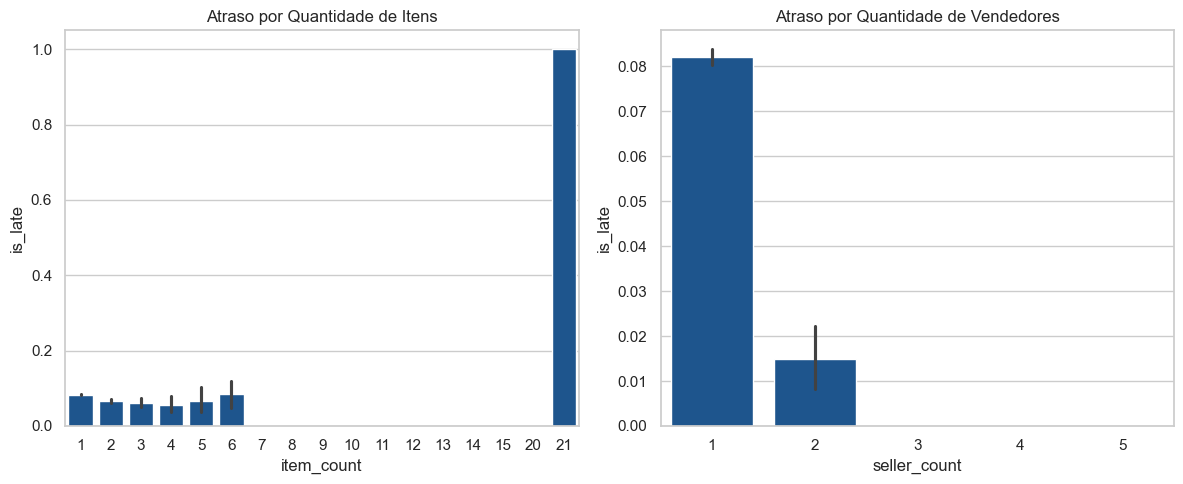

,total_price,total_freight
is_late,,
0,85.5,17.070
1,89.9,18.055


In [20]:
# Avaliando complexidade por quantidade de itens e vendedores
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=orders_analysis, x='item_count', y='is_late', ax=axes[0])
axes[0].set_title('Atraso por Quantidade de Itens')

sns.barplot(data=orders_analysis, x='seller_count', y='is_late', ax=axes[1])
axes[1].set_title('Atraso por Quantidade de Vendedores')

plt.tight_layout()
plt.show()

# Avaliando características contínuas (Preço e Frete)
display(orders_analysis.groupby('is_late')[['total_price', 'total_freight']].median())

**Conclusão da pergunta 3:** diferenças nas medianas parecem operacionalmente relevantes? Os boxplots mostram muita sobreposição?

A hipótese foi apenas parcialmente apoiada. O valor do frete e o preço total apontam para um risco maior em entregas mais caras/volumosas. No entanto, a quantidade de itens não apresentou impacto expressivo na maioria dos casos, e a quantidade de múltiplos vendedores mostrou uma correlação inversa à esperada.

# Pergunta 4: O risco varia geograficamente?

**Hipótese:** alguns estados apresentam maior risco devido à distância ou à infraestrutura logística.

Para evitar conclusões instáveis, mostraremos apenas estados com pelo menos 100 pedidos no recorte.

,mean,count
customer_state,,
AL,0.239295,397
MA,0.196927,716
PI,0.159664,476
CE,0.153365,1278
SE,0.152239,335
BA,0.140356,3256
RJ,0.134759,12348
TO,0.127737,274
PA,0.123679,946


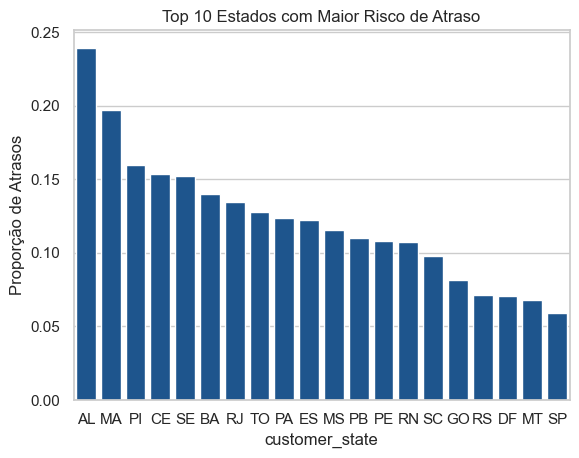

In [24]:
# Agrupando por estado e filtrando os que têm pelo menos 100 pedidos
risco_estado = orders_analysis.groupby('customer_state')['is_late'].agg(['mean', 'count'])
risco_estado_filtrado = risco_estado[risco_estado['count'] >= 100].sort_values('mean', ascending=False)

display(risco_estado_filtrado)

# Visualização dos 26 estados com maior risco
sns.barplot(x=risco_estado_filtrado.head(20).index, y=risco_estado_filtrado.head(20)['mean'])
plt.title("Top 10 Estados com Maior Risco de Atraso")
plt.ylabel("Proporção de Atrasos")
plt.show()

**Conclusão da pergunta 4:** localização pode ser útil, mas “estado” talvez esteja representando outros fatores não observados. Que fatores seriam esses?



Sim, o risco varia significativamente dependendo da geografia. Os dados mostram que os estados com as maiores taxas de atraso estão concentrados na região Nordeste (AL com 23,9%, MA com 19,6%, PI com 15,9%, CE com 15,3%, SE com 15,2% e BA com 14,0%). Na outra ponta, estados do Sul e Sudeste, como SP (5,8%), MG (5,6%) e PR (4,9%), apresentam as menores taxas, concentrando também a esmagadora maioria do volume de pedidos.

O "estado" atua como uma representação (proxy) de outros fatores operacionais não observados diretamente na tabela, tais como:

Distância física: A vasta maioria dos lojistas e centros de distribuição da Olist provavelmente ficam em São Paulo. Logo, entregas para o Nordeste percorrem trajetos muito maiores.

Malha logística: Dependência de múltiplos modais e transportadoras parceiras (redespacho) para acessar regiões mais distantes dos grandes eixos.

Fatores locais: O Rio de Janeiro (RJ) chama a atenção por estar no Sudeste, mas possuir uma taxa de atraso alta (13,4%), o que frequentemente se explica por áreas com restrição de entrega devido a questões de segurança pública, forçando a devolução ou atraso no roteiro das transportadoras.

# Pergunta 5: O momento da compra está associado ao atraso?

**Hipótese:** determinados meses enfrentam maior pressão logística e apresentam maior taxa de atraso.

,mean,count
purchase_month,,
1,0.062300,7817
2,0.134334,8196
3,0.171536,9549
4,0.059554,9101
5,0.066446,10294
6,0.022099,9231
7,0.040786,10028
8,0.075778,10544
9,0.052277,4151


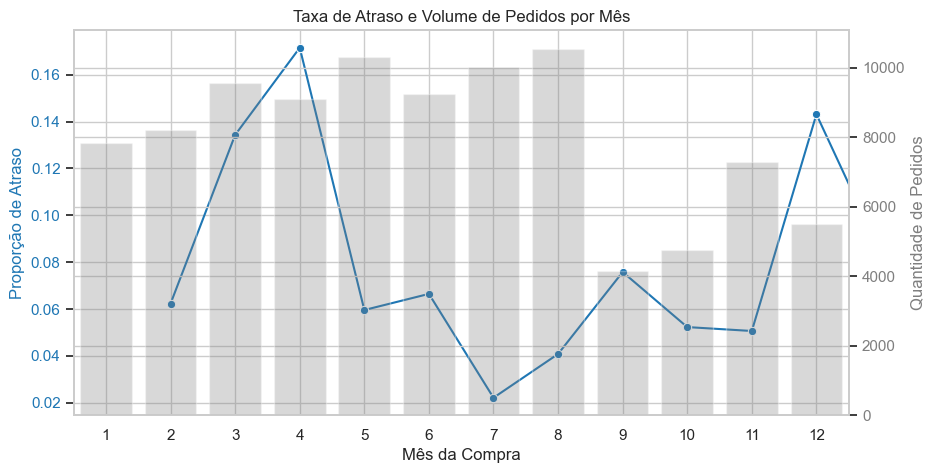

In [25]:
# Agrupando por mês da compra
risco_mes = orders_analysis.groupby('purchase_month')['is_late'].agg(['mean', 'count'])
display(risco_mes)

# Plotando volume de vendas vs taxa de atrasos
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Mês da Compra')
ax1.set_ylabel('Proporção de Atraso', color=color)
sns.lineplot(data=risco_mes, x=risco_mes.index, y='mean', marker='o', ax=ax1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:gray'
ax2.set_ylabel('Quantidade de Pedidos', color=color)  
sns.barplot(x=risco_mes.index, y=risco_mes['count'], alpha=0.3, ax=ax2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Taxa de Atraso e Volume de Pedidos por Mês")
plt.show()

**Conclusão da pergunta 5:** há indícios de sazonalidade? Compare também a quantidade de pedidos por mês antes de concluir.



Resumo para a conclusão do notebook:
A hipótese foi apoiada: O momento da compra tem forte associação com a taxa de atraso.

Volume vs. Capacidade: A relação não é linear. Meses com volumes muito altos conseguem operar com baixa taxa de atraso, enquanto picos de atraso ocorrem tanto em eventos sazonais de alta demanda quanto em períodos de instabilidade operacional pontual.

Implicação para a modelagem: O mês e o período da compra são variáveis relevantes para o modelo, mas devem ser avaliados com divisão temporal (train/test temporal) para evitar que oscilações pontuais de um ano específico contaminem o aprendizado geral do modelo.